In [994]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# Reading in data

In [995]:
#Raw Data

MCSLC_data = pd.read_excel("data/MCSLC.xlsx")
SPD_Calls_data = pd.read_excel("data/2015-2025 SPD Calls for Service.xlsx")
SPD_Responding_data = pd.read_excel("data/2015-2025 SPD Responding Units.xlsx")
SPD_Full = pd.read_excel("data/SPD_FULL.xlsx")

In [996]:
#CAD data

CAD_2015 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2015noloc.csv")
CAD_2016 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2016noloc.csv")
CAD_2017 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2017noloc.csv")
CAD_2018 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2018noloc.csv")
CAD_2019 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2019noloc.csv")
CAD_2020 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2020noloc.csv")
CAD_2021 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv", low_memory=False)
CAD_2022 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2022noloc.csv")
CAD_2023 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2023noloc.csv")
CAD_2024 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2024noloc.csv")
CAD_2025 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv", low_memory=False)


CAD_total = pd.concat([CAD_2015,
                       CAD_2016,
                       CAD_2017,
                       CAD_2018,
                       CAD_2019,
                       CAD_2020,
                       CAD_2021,
                       CAD_2022,
                       CAD_2023,
                       CAD_2024,
                       CAD_2025])

In [997]:
CAD_total.head()

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month
0,2015,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,PERSON STOP,ASST,ASSISTED,0.0,0.0,217,1,1,6,_5E48,1,1,NaN
1,2015,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,FIGHT,RSLV,RESOLVED,0.0,0.0,2114,1,1,P,_3F65,4,2,NaN
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,_3J79,1,1,NaN
3,2015,EPD,LAW,15000007,2015-01-01 00:03:16.000,NaN,W911,SHOTS FIRED,PCHK,PATROL CHECK,277.0,576.0,891,1,1,3,_5E48,2,2,NaN
4,2015,EPD,LAW,15000010,2015-01-01 00:03:34.000,NaN,SELF,ILLEGAL FIREWORKS,ADVI,ADVISED,0.0,0.0,150,1,1,5,_5K97,1,1,NaN


In [998]:
SPD_Full.head()

,Incident Number,Initial Call Type,Final Call Type,Responding Agency,Primary Responding Unit,Call Creation Time,First Dispatched Time,First Arrival Time,Clear Time,Priority,Call Creation Mechanism
0,15000074.0,ALMAUD,AUDIBLE ALARM,SPD,1S18,2015-01-01 01:16:21,2015-01-01 01:18:28,2015-01-01 01:21:13,2015-01-01 01:32:08,3,PHONE
1,15000083.0,TRFSTP,DWS,SPD,3D2,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:34:57,4,SELF
2,15000167.0,MVAUNK,MOTOR VEH ACC UNKNOWN INJ,SPD,,2015-01-01 03:15:28,NaT,NaT,NaT,3,E911
3,15000216.0,TRFSTP,DWS,SPD,1S22,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:38:53,4,SELF
4,15000222.0,SUSPVE,SUSPICIOUS VEHICLE,SPD,1S11,2015-01-01 05:52:53,2015-01-01 05:53:57,2015-01-01 05:56:21,2015-01-01 06:04:04,3,PHONE


In [999]:
MCSLC_data.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,5.0,NaN,0.0,NaN
1,12574,Cancelled,Unknown,2025-12-05 17:41:00,2025-12-05 17:47:00,2025-12-05 18:06:00,NaT,2025-12-05 18:12:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,6.0,19.0,NaN,NaN
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,4.0,14.0,2.0,8.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,14.0,38.0,7.0,37.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,NaN,Arrest,2.0,11.0,2.0,27.0


# CLEANING/PROCESSING STAGE

## simplifying dates

In [1000]:
#date that CAHOOTS ceased operation in Eugene

CAHOOTS_closure = dt.datetime(2025, 4, 7)

In [1001]:
#Create a simplified date column for Eugene CAD data.

CAD_total["Date"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m")
CAD_total["Date"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m")

CAD_total["Day"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m-%d")
CAD_total["Day"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m-%d")

CAD_total["CAHOOTS_closed"] = np.where(CAD_total["Day"] > CAHOOTS_closure, True, False)


In [1002]:
#Creating simplified date column for MCSLC data.

MCSLC_data["Date"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m")
MCSLC_data["Date"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m")

MCSLC_data["Day"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m-%d")
MCSLC_data["Day"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m-%d")

MCSLC_data["CAHOOTS_closed"] = np.where(MCSLC_data["Day"] > CAHOOTS_closure, True, False)

In [1003]:
#Creating simplified date column for SPD data.

SPD_Full["Date"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m")
SPD_Full["Date"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m")

SPD_Full["Day"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m-%d")
SPD_Full["Day"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m-%d")

SPD_Full["CAHOOTS_closed"] = np.where(SPD_Full["Day"] > CAHOOTS_closure, True, False)

## Subsetting MCSLC data by city

In [1004]:
#Subsetting MCSLC data by City

MCSLC_Eugene = MCSLC_data[MCSLC_data["City"] == 'Eugene'].reset_index()
MCSLC_Springfield = MCSLC_data[MCSLC_data["City"] == 'Springfield'].reset_index()

## Subsetting Eugene and Springfield data by agency

In [1005]:
#Known CAHOOTS unit codes

#Cahoots_codes1 = CAD_total[CAD_total["nature"] == "CHECK WELFARE, CAHOOTS"]["primeunit"].unique()
Cahoots_codes = np.array(['_CAHOT ', '_TESTCA', '_1J77  ', '_3J78  ', '_4J79  ', '_3J77  ', '_3J79  ',
                          '3J81  ', '3J76  ', '2J28  ', '2J29  ', 'CAHOOT  ', 'CAHOT  ', 'CAHO  '])

In [1006]:
EUG_DATA = CAD_total.copy()
SPR_DATA = SPD_Full.copy()

In [1007]:
EUG_DATA["OLD_AGENCY"] = EUG_DATA["agency"]

In [1008]:
EUG_DATA

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,...,arrv,priority,primeunit,units_dispd,units_arrived,month,Date,Day,CAHOOTS_closed,OLD_AGENCY
0,2015,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,PERSON STOP,ASST,ASSISTED,...,1,6,_5E48,1,1,NaN,2015-01-01,2015-01-01,False,EPD
1,2015,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,FIGHT,RSLV,RESOLVED,...,1,P,_3F65,4,2,NaN,2015-01-01,2015-01-01,False,EPD
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,...,1,5,_3J79,1,1,NaN,2015-01-01,2015-01-01,False,EPD
3,2015,EPD,LAW,15000007,2015-01-01 00:03:16.000,NaN,W911,SHOTS FIRED,PCHK,PATROL CHECK,...,1,3,_5E48,2,2,NaN,2015-01-01,2015-01-01,False,EPD
4,2015,EPD,LAW,15000010,2015-01-01 00:03:34.000,NaN,SELF,ILLEGAL FIREWORKS,ADVI,ADVISED,...,1,5,_5K97,1,1,NaN,2015-01-01,2015-01-01,False,EPD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117347,2025,EPD,LAW,25327368,2025-12-31 23:39:12.000,NaN,SELF,TRAFFIC STOP,SBCK,SOBRIETY CHECK,...,1,6,_4U41,1,1,12.0,2025-12-01,2025-12-01,True,EPD
117348,2025,EPD,LAW,25327370,2025-12-31 23:40:48.000,NaN,SELF,TRAFFIC STOP,UTC,UNIFORM TRAFFIC CITATION ISSUED,...,1,6,_5E56,2,2,12.0,2025-12-01,2025-12-01,True,EPD
117349,2025,EPD,LAW,25327374,2025-12-31 23:45:57.000,NaN,SELF,PATROL CHECK,UTC,UNIFORM TRAFFIC CITATION ISSUED,...,1,6,_4E48,3,3,12.0,2025-12-01,2025-12-01,True,EPD
117350,2025,EPD,LAW,25327376,2025-12-31 23:49:12.000,NaN,SELF,ASSIST OREGON STATE POLICE,ASST,ASSISTED,...,1,P,_5T81,1,1,12.0,2025-12-01,2025-12-01,True,EPD


In [1009]:
#Subsetting Eugene and Springfield call data by known CAHOOTS unit codes

EUG_DATA["agency"] = np.where(EUG_DATA["primeunit"].isin(Cahoots_codes), "CAHOOTS_EUG", "EPD")
SPR_DATA["Responding Agency"] = np.where(SPR_DATA["Primary Responding Unit"].isin(Cahoots_codes), "CAHOOTS_SPR", "SPD")

EPD = EUG_DATA[EUG_DATA["agency"] == "EPD"].reset_index()
CAHOOTS_EUG = EUG_DATA[EUG_DATA["agency"] == "CAHOOTS_EUG"].reset_index()

SPD = SPR_DATA[SPR_DATA["Responding Agency"] == "SPD"].reset_index()
CAHOOTS_SPR = SPR_DATA[SPR_DATA["Responding Agency"] == "CAHOOTS_SPR"].reset_index()

#CAHOOTS_EUG = CAD_total[CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()
#EPD = CAD_total[~CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()

#CAHOOTS_SPR = SPD_Full[SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()
#SPD = SPD_Full[~SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()


## Identifying most common CAHOOTS/MCSLC call types

In [1010]:
#Identifying most common CAHOOTS call types in Eugene

Top_Cahoots_natures_EUG = CAHOOTS_EUG.groupby('nature')["yr"].count().sort_values(ascending=False)
Top_Cahoots_natures_EUG[:25]

nature
ASSIST PUBLIC- POLICE           39540
CHECK WELFARE                   35105
TRANSPORT                       25035
PUBLIC ASSIST, CAHOOTS          19173
CHECK WELFARE, CAHOOTS          15793
SUICIDAL SUBJECT                 6132
TRANSPORT, CAHOOTS               4751
SUICIDAL SUBJECT, CAHOOTS        4344
INTOXICATED SUBJECT              2476
ASSIST PD, CAHOOTS               2175
INFO / ATL, CAHOOTS              1938
FOUND SYRINGE                    1860
DISORDERLY SUBJECT               1666
TRAFFIC HAZARD                   1654
ASSIST FIRE DEPARTMENT           1229
DISORDERLY SUBJECT, CAHOOTS      1184
TRAFFIC HAZARD, CAHOOTS          1053
DISORIENTED SUBJECT               727
ASSIST FD, CAHOOTS                681
INTOXICATED SUBJECT, CAHOOTS      657
CRIMINAL TRESPASS                 593
DISORIENTED SUBJECT, CAHOOTS      580
SUBJECT DOWN                      495
FOUND SYRINGE, CAHOOTS            473
CITIZEN CONTACT                   464
Name: yr, dtype: int64

In [1011]:
Top_Cahoots_natures_EUG[25:50]

nature
PERSON STOP               308
SUSPICIOUS CONDITIONS     287
DISPUTE                   236
OVERDOSE                  231
DISORDERLY JUVENILES      215
FLAGGED DOWN              175
PATROL CHECK              158
UNKNOWN PROBLEM           149
NUDE SUBJECT              146
SUSPICIOUS SUBJECT        144
FOLLOW UP                 139
DEATH MESSAGE             132
ASSIST OUTSIDE AGENCY      83
EMERGENCY MESSAGE          77
ATTEMPT TO LOCATE          69
BEAT INFORMATION           69
INFORMATION - POLICE       50
SUBJECT SCREAMING          39
ASSAULT WITH INJURY        36
INDECENT EXPOSURE          36
ASSAULT                    28
HARASSMENT                 28
INJURED SUBJECT            26
ASSIST SHERIFFS OFFICE     23
ILLEGAL CAMPING            23
Name: yr, dtype: int64

In [1012]:
Top_Cahoots_natures_EUG[50:75]

nature
POISONING                    21
TRAFFIC STOP                 21
HAZARD SAFETY                21
MISSING PERSON               21
INCOMPLETE CALL              18
DISPUTE FAMILY               16
CARDIAC ARREST               16
BURGLARY                     15
MOTOR VEH ACC UNKNOWN INJ    13
ACCIDENT BIKE                13
INJURED ANIMAL               11
DISABLED VEHICLE             11
RUNAWAY JUVENILE             11
MOTOR VEH ACC NO INJURY      11
THEFT                        11
ANIMAL COMPLAINT             10
OPEN CONTAINER               10
UNATTENDED CHILDREN          10
LOUD NOISE                    9
DOG AT LARGE                  9
ANIMAL CRUELTY                9
LOST SUBJECT                  8
ILLEGAL BURNING               8
DRUG INFO                     8
PROWLER                       8
Name: yr, dtype: int64

In [1013]:
#Identifying most common CAHOOTS call types in Springfield

Top_Cahoots_natures_SPR = CAHOOTS_SPR.groupby("Final Call Type")['Incident Number'].count().sort_values(ascending=False)

Top_Cahoots_natures_SPR[:25]

Final Call Type
CHECK WELFARE             18126
ASSIST PUBLIC- POLICE     16656
SUICIDAL SUBJECT           1975
INTOXICATED SUBJECT        1161
DISORDERLY SUBJECT          662
FOUND SYRINGE               619
TRANSPORT                   544
CRIMINAL TRESPASS           405
TRAFFIC HAZARD              357
ASSIST FIRE DEPARTMENT      345
DISORDERLY JUVENILES        332
SUBJECT DOWN                299
FLAGGED DOWN                228
SUSPICIOUS CONDITIONS       227
DISORIENTED SUBJECT         202
DISPUTE                     196
SUSPICIOUS SUBJECT          175
PERSON STOP                 161
DETOXIFICATION              138
UNKNOWN PROBLEM             126
OVERDOSE                     96
FOLLOW UP                    89
SUBJECT SCREAMING            88
ILLEGAL CAMPING              80
ASSIST OUTSIDE AGENCY        71
Name: Incident Number, dtype: int64

In [1014]:
#Identifying most common MCSLC call types

Top_MCSLC_natures = MCSLC_data.groupby("Reason for Dispatch #1")["ID"].count().sort_values(ascending=False)
Top_MCSLC_natures

Reason for Dispatch #1
Agitation or disruptive behavior             1492
Suicidality or suicide attempt                681
Disorganized behavior                         654
Needing social/mental health services         528
Difficulty functioning                        409
Harm/risk of harm to self/others/property     330
Paranoia                                      116
Substance use                                 115
Adult Social/interpersonal problems           114
Other                                          50
Trauma                                         35
Running away                                   18
Concerns about treatment engagement            15
Name: ID, dtype: int64

In [1015]:
MCSLC_data

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Date,Day,CAHOOTS_closed
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,NaN,NaN,Arrest,5.0,NaN,0.0,NaN,2025-05-01,2025-05-01,True
1,12574,Cancelled,Unknown,2025-12-05 17:41:00,2025-12-05 17:47:00,2025-12-05 18:06:00,NaT,2025-12-05 18:12:00,Agitation or disruptive behavior,NaN,...,NaN,NaN,Arrest,6.0,19.0,NaN,NaN,2025-12-01,2025-12-01,True
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,...,NaN,NaN,Arrest,4.0,14.0,2.0,8.0,2025-07-01,2025-07-01,True
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,NaN,NaN,Arrest,14.0,38.0,7.0,37.0,2025-03-01,2025-03-01,False
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,...,NaN,NaN,Arrest,2.0,11.0,2.0,27.0,2025-04-01,2025-04-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4677,14295,NaN,Eugene,2025-11-20 03:23:00,2025-11-20 05:12:00,2025-11-20 05:22:00,2025-11-20 05:22:00,2025-11-20 06:02:00,Harm/risk of harm to self/others/property,Needing social/mental health services,...,NaN,NaN,Sobering/Detox Facility,109.0,10.0,0.0,40.0,2025-11-01,2025-11-01,True
4678,14404,NaN,Eugene,2025-09-07 00:13:00,2025-09-07 00:21:00,2025-09-07 00:32:00,2025-09-07 00:33:00,2025-09-07 00:57:00,Harm/risk of harm to self/others/property,Adult Social/interpersonal problems,...,NaN,NaN,Sobering/Detox Facility,8.0,11.0,1.0,25.0,2025-09-01,2025-09-01,True
4679,14495,NaN,Eugene,2025-11-10 04:19:00,2025-11-10 04:25:00,2025-11-10 04:36:00,2025-11-10 04:36:00,2025-11-10 05:17:00,Disorganized behavior,Difficulty functioning,...,NaN,NaN,Sobering/Detox Facility,6.0,11.0,0.0,41.0,2025-11-01,2025-11-01,True
4680,14628,NaN,Eugene,2025-10-07 02:48:00,2025-10-07 03:06:00,2025-10-07 03:18:00,2025-10-07 03:20:00,2025-10-07 04:05:00,Disorganized behavior,NaN,...,NaN,NaN,Sobering/Detox Facility,18.0,12.0,2.0,47.0,2025-10-01,2025-10-01,True


## Subsetting by call type

In [1016]:
#EPD/SPD call type codes
#Welfare check
EPD_welfare_check_codes = ["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"]

EPD_welfare = EPD[EPD["nature"].isin(EPD_welfare_check_codes)].reset_index()
SPD_welfare = SPD[SPD["Final Call Type"].isin(EPD_welfare_check_codes)].reset_index()

#Transport
EPD_transport_codes = ["TRANSPORT"]

EPD_transport = EPD[EPD["nature"].isin(EPD_transport_codes)].reset_index()
SPD_transport = SPD[SPD["Final Call Type"].isin(EPD_transport_codes)].reset_index()

#Intoxicated subject
EPD_intoxicated_codes = ["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"]

EPD_intoxicated = EPD[EPD["nature"].isin(EPD_intoxicated_codes)].reset_index()
SPD_intoxicated = SPD[SPD["Final Call Type"].isin(EPD_intoxicated_codes)].reset_index()

#Suicidal Subject
EPD_suicidal_codes = ["SUICIDAL SUBJECT"]

EPD_suicidal = EPD[EPD["nature"].isin(EPD_suicidal_codes)].reset_index()
SPD_suicidal = SPD[SPD["Final Call Type"].isin(EPD_suicidal_codes)].reset_index()

#public assist
EPD_public_assist_codes = ["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"]

EPD_public_assist = EPD[EPD["nature"].isin(EPD_public_assist_codes)].reset_index()
SPD_public_assist = SPD[SPD["Final Call Type"].isin(EPD_public_assist_codes)].reset_index()

In [1084]:
#selected codes
call_types_eug_spr = ["CHECK WELFARE", "CHECK WELFARE, CAHOOTS",
                      "TRANSPORT", "TRANSPORT, CAHOOTS",
                      "INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS",
                      "SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS",
                      "ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"]

#Eugene
EUG_TYPES = EUG_DATA[EUG_DATA["nature"].isin(call_types_eug_spr)]
EUG_TYPES = EUG_TYPES.rename(columns = {"nature": "call type"})

#Springfield
SPR_TYPES = SPR_DATA[SPR_DATA["Final Call Type"].isin(call_types_eug_spr)]
SPR_TYPES = SPR_TYPES.rename(columns = {"Final Call Type": "call type"})
SPR_TYPES = SPR_TYPES.rename(columns = {"Responding Agency": "agency"})

#MCLSC
#TODO

In [1085]:
#Renaming call types
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"], "CHECK WELFARE")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["TRANSPORT", "TRANSPORT, CAHOOTS"], "TRANSPORT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"], "INTOXICATED SUBJECT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS"], "SUICIDAL SUBJECT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"], "ASSIST PUBLIC")

SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"], "CHECK WELFARE")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["TRANSPORT", "TRANSPORT, CAHOOTS"], "TRANSPORT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"], "INTOXICATED SUBJECT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS"], "SUICIDAL SUBJECT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"], "ASSIST PUBLIC")

In [1086]:
SPR_TYPES["call type"].unique()

array(['TRANSPORT', 'SUICIDAL SUBJECT', 'CHECK WELFARE',
       'INTOXICATED SUBJECT', 'ASSIST PUBLIC'], dtype=object)

In [1087]:
l = SPR_TYPES[SPR_TYPES["Date"] == dt.datetime(2025,1,1)]
l = l[l["agency"] == "CAHOOTS_SPR"]
l["call type"].unique()

array(['CHECK WELFARE', 'ASSIST PUBLIC', 'INTOXICATED SUBJECT',
       'SUICIDAL SUBJECT'], dtype=object)

In [1088]:
EUG_DATA[EUG_DATA["inci_id"] == 25003327]

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,...,arrv,priority,primeunit,units_dispd,units_arrived,month,Date,Day,CAHOOTS_closed,OLD_AGENCY
1243,2025,CAHOOTS_EUG,OTHR,25003327,2025-01-04 21:09:37.000,NaN,PHONE,"SUICIDAL SUBJECT, CAHOOTS",ASST,ASSISTED,...,1,5,_4J79,1,1,1.0,2025-01-01,2025-01-01,False,CAHE


In [1089]:
EUG_TYPES[EUG_TYPES["inci_id"] == 25003327]

,yr,agency,service,inci_id,calltime,case_id,callsource,call type,closecode,closed_as,...,arrv,priority,primeunit,units_dispd,units_arrived,month,Date,Day,CAHOOTS_closed,OLD_AGENCY
1243,2025,CAHOOTS_EUG,OTHR,25003327,2025-01-04 21:09:37.000,NaN,PHONE,SUICIDAL SUBJECT,ASST,ASSISTED,...,1,5,_4J79,1,1,1.0,2025-01-01,2025-01-01,False,CAHE


In [1090]:
t = EUG_TYPES[EUG_TYPES["Date"] == dt.datetime(2025,1,1)]
t = t[t["agency"] == "CAHOOTS_EUG"]
t

,yr,agency,service,inci_id,calltime,case_id,callsource,call type,closecode,closed_as,...,arrv,priority,primeunit,units_dispd,units_arrived,month,Date,Day,CAHOOTS_closed,OLD_AGENCY
43,2025,CAHOOTS_EUG,OTHR,25000104,2025-01-01 03:13:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,...,0,7,_1J77,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
55,2025,CAHOOTS_EUG,OTHR,25000138,2025-01-01 05:07:39.000,NaN,PHONE,ASSIST PUBLIC,GOA,GONE ON ARRIVAL,...,1,7,_1J77,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
57,2025,CAHOOTS_EUG,OTHR,25000142,2025-01-01 05:10:13.000,NaN,PHONE,SUICIDAL SUBJECT,ASST,ASSISTED,...,0,7,_1J77,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
62,2025,CAHOOTS_EUG,OTHR,25000166,2025-01-01 06:22:36.000,NaN,PHONE,ASSIST PUBLIC,ASST,ASSISTED,...,1,7,_1J77,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
65,2025,CAHOOTS_EUG,OTHR,25000173,2025-01-01 06:41:52.000,NaN,PHONE,ASSIST PUBLIC,UTL,UNABLE TO LOCATE,...,1,7,_1J77,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10857,2025,CAHOOTS_EUG,OTHR,25027696,2025-01-31 22:20:37.000,NaN,PHONE,CHECK WELFARE,UTL,UNABLE TO LOCATE,...,1,7,_4J79,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
10864,2025,CAHOOTS_EUG,OTHR,25027713,2025-01-31 22:39:15.000,NaN,W911,INTOXICATED SUBJECT,UTL,UNABLE TO LOCATE,...,1,7,_4J79,1,1,1.0,2025-01-01,2025-01-01,False,CAHE
10866,2025,CAHOOTS_EUG,OTHR,25027716,2025-01-31 22:43:26.000,NaN,PHONE,CHECK WELFARE,DIS,DISREGARD,...,0,5,_CAHOT,0,0,1.0,2025-01-01,2025-01-01,False,CAHE
10876,2025,CAHOOTS_EUG,OTHR,25027730,2025-01-31 23:07:25.000,NaN,PHONE,ASSIST PUBLIC,GOA,GONE ON ARRIVAL,...,0,7,_4J79,1,1,1.0,2025-01-01,2025-01-01,False,CAHE


## Creating total call volume dataframes

In [1091]:
#Monthly call volume data frames for CAHOOTS, EPD, and SPD data

CAHOOTS_EUG_VOLUME = CAHOOTS_EUG.groupby("Date")["inci_id"].count().reset_index().rename(columns = {"inci_id": "CH_EUG_CALLS"})
CAHOOTS_EUG_VOLUME = CAHOOTS_EUG_VOLUME.rename(columns = {"inci_id": "CH_EUG_CALLS"})

CAHOOTS_SPR_VOLUME = CAHOOTS_SPR.groupby("Date")["Incident Number"].count().reset_index()
CAHOOTS_SPR_VOLUME = CAHOOTS_SPR_VOLUME.rename(columns = {"Incident Number": "CH_SPR_CALLS"})

EPD_VOLUME = EPD.groupby("Date")["inci_id"].count().reset_index()
EPD_VOLUME = EPD_VOLUME.rename(columns = {"inci_id": "EPD_CALLS"})

SPD_VOLUME = SPD.groupby("Date")["Incident Number"].count().reset_index()
SPD_VOLUME = SPD_VOLUME.rename(columns = {"Incident Number": "SPD_CALLS"})

#Monthly call volume data frame for MCSLSC
MCSLC_EUG_VOLUME = MCSLC_Eugene.groupby("Date")["ID"].count().reset_index()
MCSLC_EUG_VOLUME = MCSLC_EUG_VOLUME.rename(columns = {"ID": "MCSLC_EUG_CALLS"})

MCSLC_SPR_VOLUME = MCSLC_Springfield.groupby("Date")["ID"].count().reset_index()
MCSLC_SPR_VOLUME = MCSLC_SPR_VOLUME.rename(columns = {"ID": "MCSLC_SPR_CALLS"})

#Total Eugene call volumes
TOTAL_EUG_VOLUME = EPD_VOLUME.merge(CAHOOTS_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.merge(MCSLC_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.fillna(0)

#Total Springfield call volumes
TOTAL_SPR_VOLUME = SPD_VOLUME.merge(CAHOOTS_SPR_VOLUME, on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.merge(MCSLC_SPR_VOLUME, how = "left", on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.fillna(0)

In [1092]:
TOTAL_SPR_VOLUME

,Date,SPD_CALLS,CH_SPR_CALLS,MCSLC_SPR_CALLS
0,2015-01-01,4703,63,0.0
1,2015-02-01,4245,123,0.0
2,2015-03-01,4529,127,0.0
3,2015-04-01,4496,109,0.0
4,2015-05-01,4493,135,0.0
...,...,...,...,...
127,2025-08-01,3523,175,37.0
128,2025-09-01,3242,144,35.0
129,2025-10-01,3440,139,33.0
130,2025-11-01,2996,174,34.0


In [1093]:
#CALL TYPE VOLUMES
EUG_TYPES_VOLUME = EUG_TYPES.groupby(["Date", "call type", "agency"])["inci_id"].count().reset_index()
EUG_TYPES_VOLUME = EUG_TYPES_VOLUME.rename(columns={"inci_id": "calls"})

SPR_TYPES_VOLUME = SPR_TYPES.groupby(["Date", "call type", "agency"])["Incident Number"].count().reset_index()
SPR_TYPES_VOLUME = SPR_TYPES_VOLUME.rename(columns={"Incident Number": "calls"})

EUG_SPR_TYPES_VOLUME = pd.concat([EUG_TYPES_VOLUME, SPR_TYPES_VOLUME])
EUG_SPR_TYPES_VOLUME

,Date,call type,agency,calls
0,2015-01-01,ASSIST PUBLIC,CAHOOTS_EUG,262
1,2015-01-01,ASSIST PUBLIC,EPD,167
2,2015-01-01,CHECK WELFARE,CAHOOTS_EUG,138
3,2015-01-01,CHECK WELFARE,EPD,191
4,2015-01-01,INTOXICATED SUBJECT,CAHOOTS_EUG,31
...,...,...,...,...
1283,2025-12-01,INTOXICATED SUBJECT,SPD,2
1284,2025-12-01,SUICIDAL SUBJECT,CAHOOTS_SPR,7
1285,2025-12-01,SUICIDAL SUBJECT,SPD,21
1286,2025-12-01,TRANSPORT,CAHOOTS_SPR,1


In [1094]:
EUG_TYPES_VOLUME["call type"].unique()

array(['ASSIST PUBLIC', 'CHECK WELFARE', 'INTOXICATED SUBJECT',
       'SUICIDAL SUBJECT', 'TRANSPORT'], dtype=object)

## Creating call type specific call volume dataframes

## Calculating call proportions by agency

In [1095]:
#Eugene call proportions
TOTAL_EUG_VOLUME["PROP_EPD"] = TOTAL_EUG_VOLUME["EPD_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_CAHOOTS_EUG"] = TOTAL_EUG_VOLUME["CH_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_MCSLC_EUG"] = TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])

#Spriungfield call proportions
TOTAL_SPR_VOLUME["PROP_SPD"] = TOTAL_SPR_VOLUME["SPD_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_CAHOOTS_SPR"] = TOTAL_SPR_VOLUME["CH_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_MCSLC_SPR"] = TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])

In [1096]:
TOTAL_EUG_VOLUME

,Date,EPD_CALLS,CH_EUG_CALLS,MCSLC_EUG_CALLS,PROP_EPD,PROP_CAHOOTS_EUG,PROP_MCSLC_EUG
0,2015-01-01,9223,880.0,0.0,0.912897,0.087103,0.000000
1,2015-02-01,8809,810.0,0.0,0.915792,0.084208,0.000000
2,2015-03-01,9663,910.0,0.0,0.913932,0.086068,0.000000
3,2015-04-01,9395,860.0,0.0,0.916138,0.083862,0.000000
4,2015-05-01,9432,859.0,0.0,0.916529,0.083471,0.000000
...,...,...,...,...,...,...,...
127,2025-08-01,10246,0.0,385.0,0.963785,0.000000,0.036215
128,2025-09-01,9773,0.0,370.0,0.963522,0.000000,0.036478
129,2025-10-01,9365,0.0,365.0,0.962487,0.000000,0.037513
130,2025-11-01,8396,0.0,333.0,0.961851,0.000000,0.038149


---

# Initial Vizualizations

In [1097]:
sns.set_style('whitegrid')

### OVERALL CALL VOLUMES AND PROPORTIONS

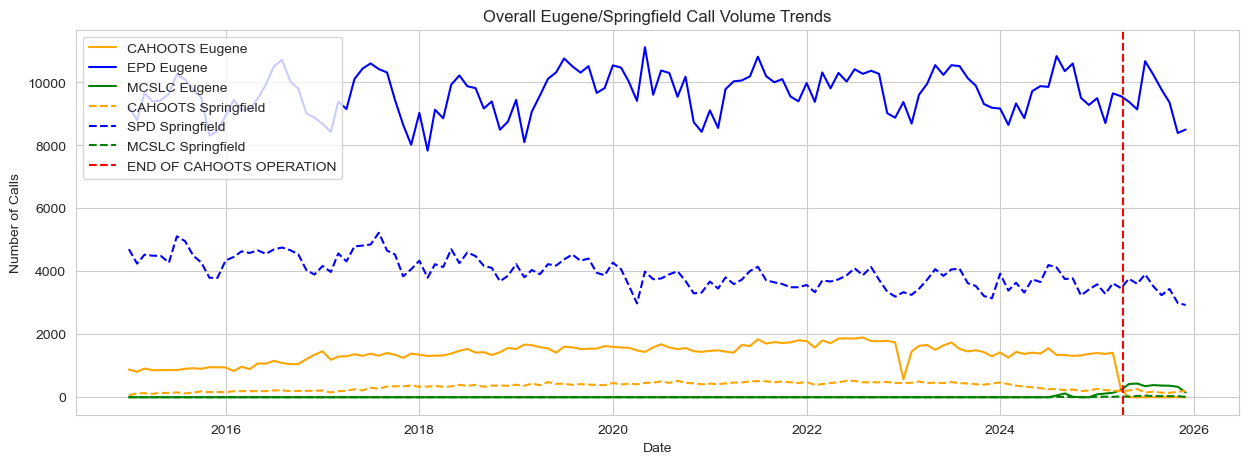

In [1098]:
#ALL RAW CALL VOLUME DATA

plt.figure(figsize=(15,5))

#Eugene Data
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")

#Springfield Data
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Overall Eugene/Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend(loc = "upper left")

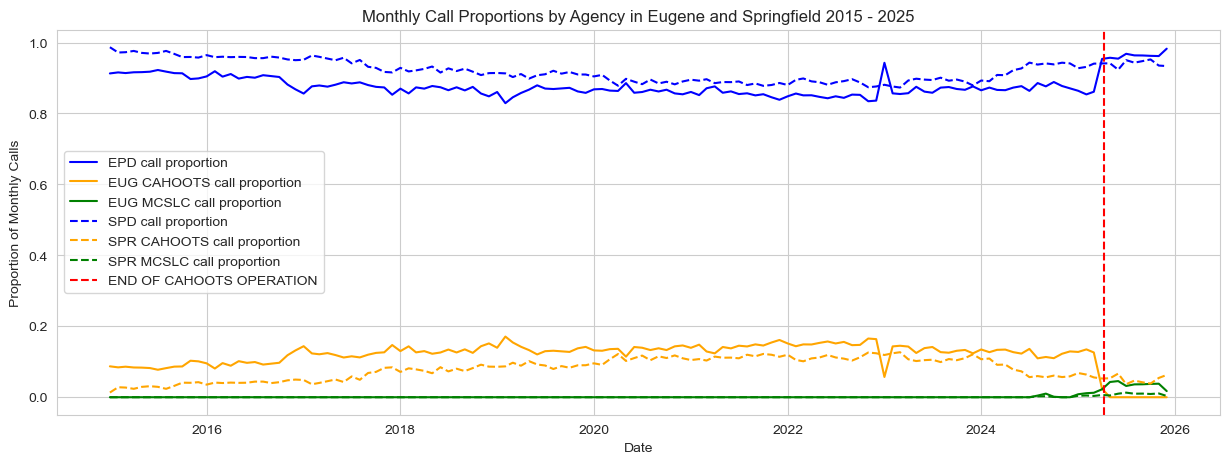

In [1099]:
#OVERALL CALL PROPORTIONS

plt.figure(figsize=(15,5))

#Eugene
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_EPD", label = "EPD call proportion", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_CAHOOTS_EUG", label = "EUG CAHOOTS call proportion", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_MCSLC_EUG", label = "EUG MCSLC call proportion", color = 'green')


#Springfield
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_SPD", label = "SPD call proportion", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_CAHOOTS_SPR", label = "SPR CAHOOTS call proportion",linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_MCSLC_SPR", label = "SPR MCSLC call proportion", linestyle = "--", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Eugene and Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

### TOTAL EUGENE CALL VOLUMES AND PROPORTIONS

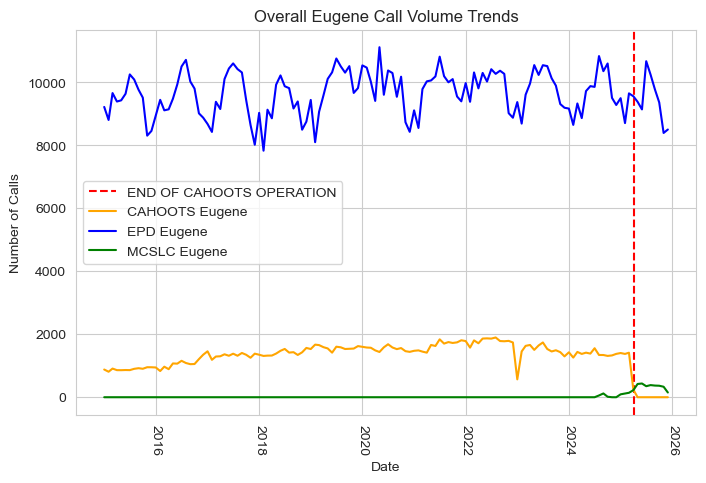

In [1100]:
#Overall Eugene Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")
plt.title("Overall Eugene Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation = -90);

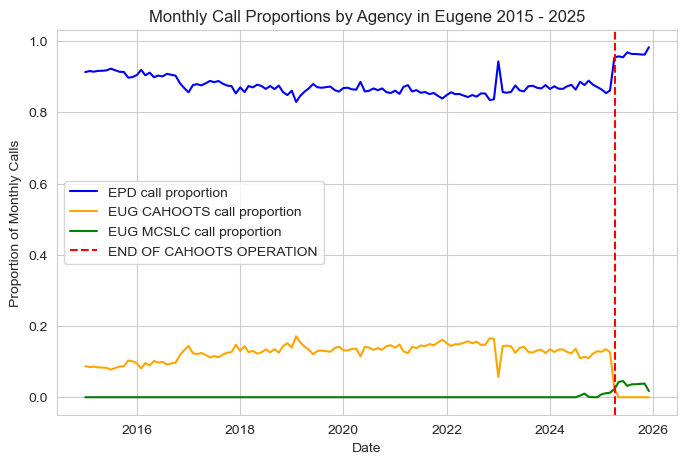

In [1101]:
plt.figure(figsize=(8,5))

#Eugene
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_EPD", label = "EPD call proportion", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_CAHOOTS_EUG", label = "EUG CAHOOTS call proportion", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_MCSLC_EUG", label = "EUG MCSLC call proportion", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Eugene 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

### TOTAL SPRINGFIELD CALL VOLUMES AND PROPORTIONS

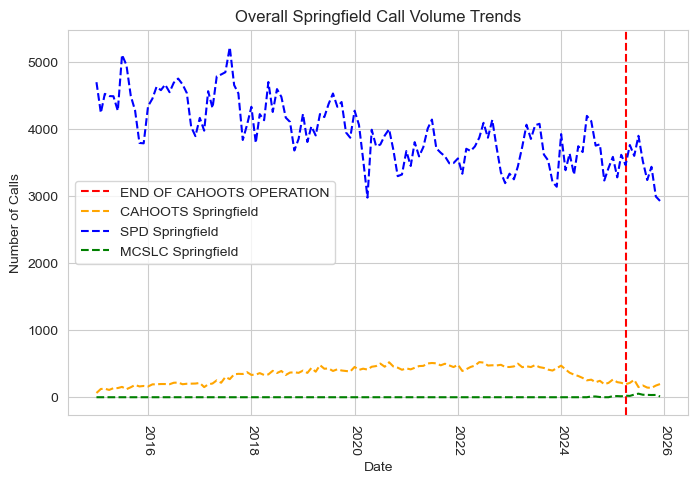

In [1102]:
#Overall Springfield Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")
plt.title("Overall Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation = -90);

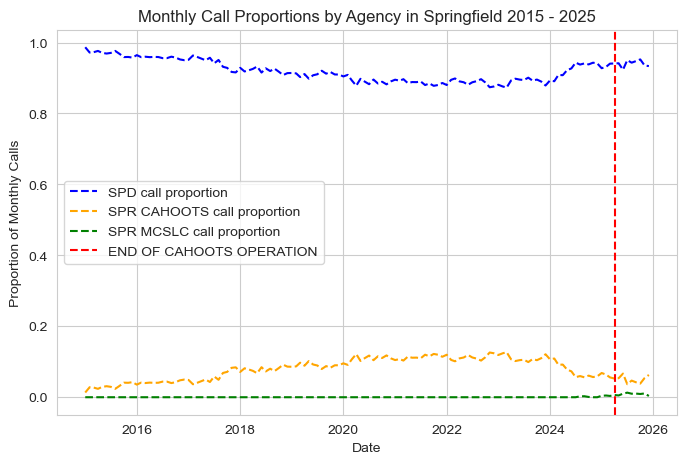

In [1103]:
#Springfield

plt.figure(figsize=(8,5))

sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_SPD", label = "SPD call proportion", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_CAHOOTS_SPR", label = "SPR CAHOOTS call proportion",linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_MCSLC_SPR", label = "SPR MCSLC call proportion", linestyle = "--", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

---

### AGENCY SPECIFIC CALL VOLUMES AND PROPORTIONS

Text(0, 0.5, 'Number of Calls')

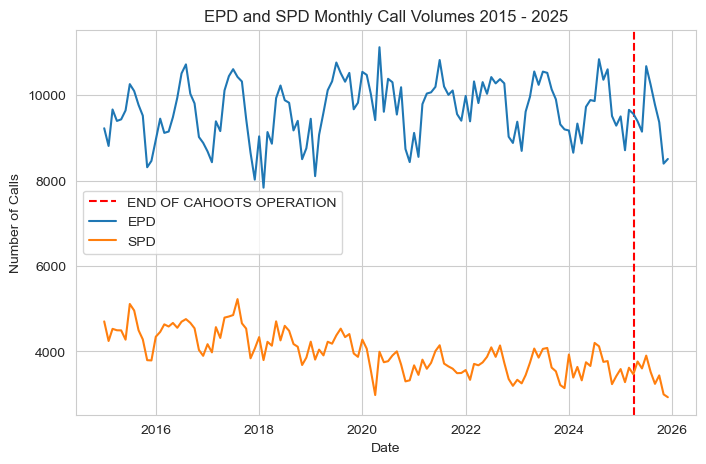

In [1104]:
#EPD vs SPD trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

#sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "EPD_CALLS", label = "EPD")
#sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "SPD_CALLS", label = "SPD")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD")

plt.title("EPD and SPD Monthly Call Volumes 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
#plt.xticks(rotation = -90);

Text(0, 0.5, 'Proportion of Monthly Calls')

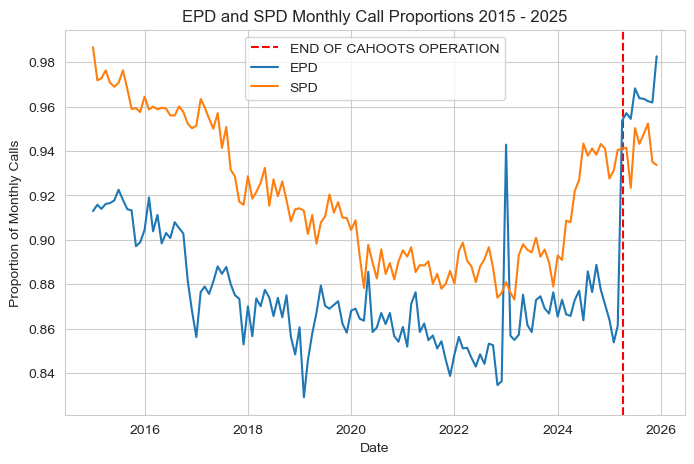

In [1105]:
#EPD and SPD Call Proportions
plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "PROP_EPD", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "PROP_SPD", label = "SPD")

plt.title("EPD and SPD Monthly Call Proportions 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
#plt.xticks(rotation = -90);


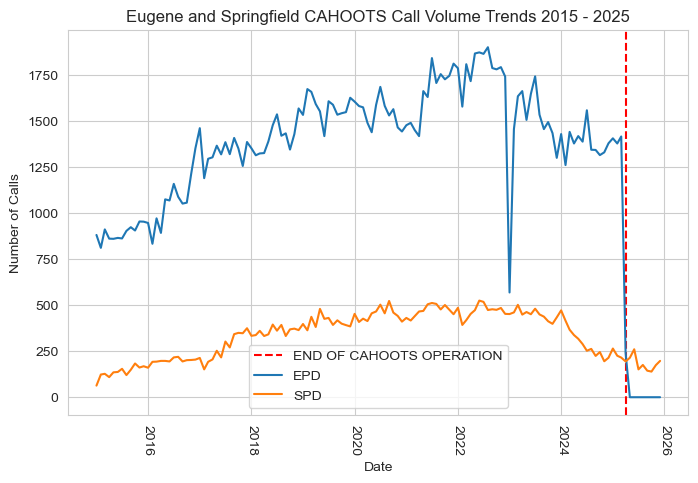

In [1106]:
#Eugene vs Springfield CAHOOTS Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "SPD")

plt.title("Eugene and Springfield CAHOOTS Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);

Text(0, 0.5, 'Proportion of Monthly Calls')

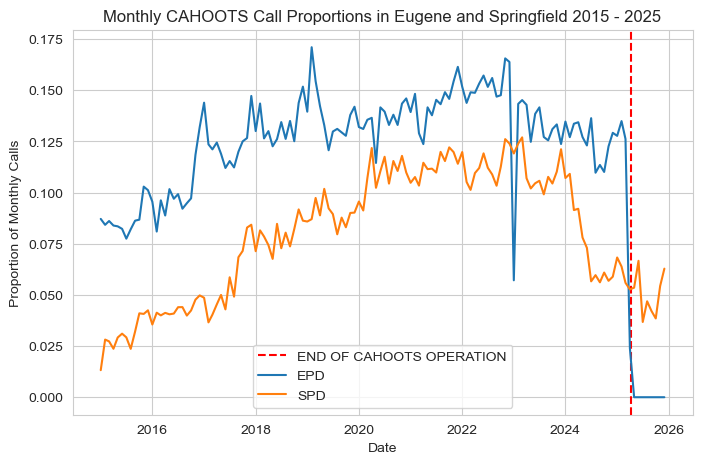

In [1107]:
#Eugene and Springfield CAHOOTS Call Proportions
plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "PROP_CAHOOTS_EUG", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "PROP_CAHOOTS_SPR", label = "SPD")

plt.title("Monthly CAHOOTS Call Proportions in Eugene and Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
#plt.xticks(rotation = -90);

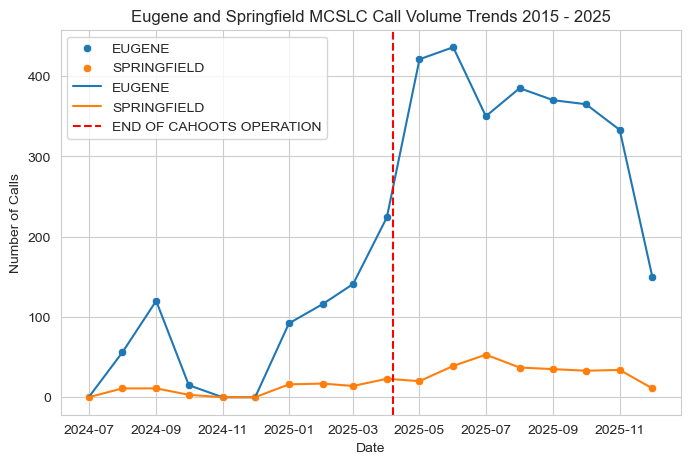

In [1108]:
#Eugene vs Springfield MCSLC Call Volume Trends
plt.figure(figsize=(8,5))

sns.scatterplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.scatterplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



plt.title("Eugene and Springfield MCSLC Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend()
#plt.xticks(rotation=45);

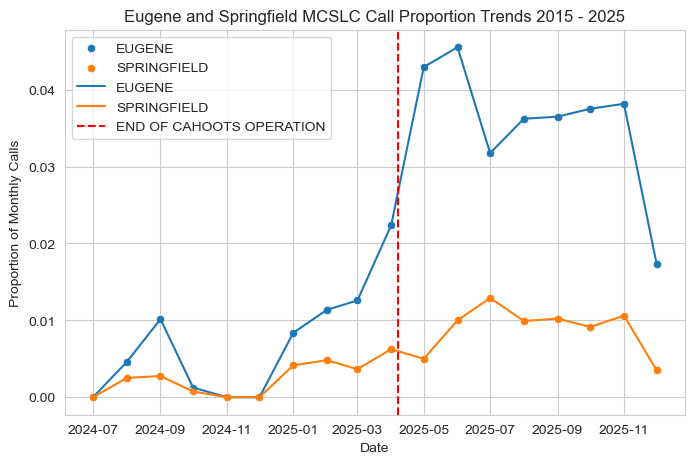

In [1109]:
#Eugene vs Springfield MCSLC Call Volume Trends
plt.figure(figsize=(8,5))

sns.scatterplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_EUG", label = "EUGENE")
sns.scatterplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_SPR", label = "SPRINGFIELD")

sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_EUG", label = "EUGENE")
sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_SPR", label = "SPRINGFIELD")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



plt.title("Eugene and Springfield MCSLC Call Proportion Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()
#plt.xticks(rotation=45);

# Call type Specific visualizations

---

In [1110]:
EPD_TYPES_VOLUME = EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["agency"] == "EPD"]
SPD_TYPES_VOLUME =SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["agency"] == "SPD"]

CAHOOTS_EUG_TYPES_VOLUME = EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["agency"] == "CAHOOTS_EUG"]
CAHOOTS_SPR_TYPES_VOLUME =SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["agency"] == "CAHOOTS_SPR"]

In [1111]:
EUG_TYPES_VOLUME["agency"].unique()

array(['CAHOOTS_EUG', 'EPD'], dtype=object)

<Axes: xlabel='Date', ylabel='calls'>

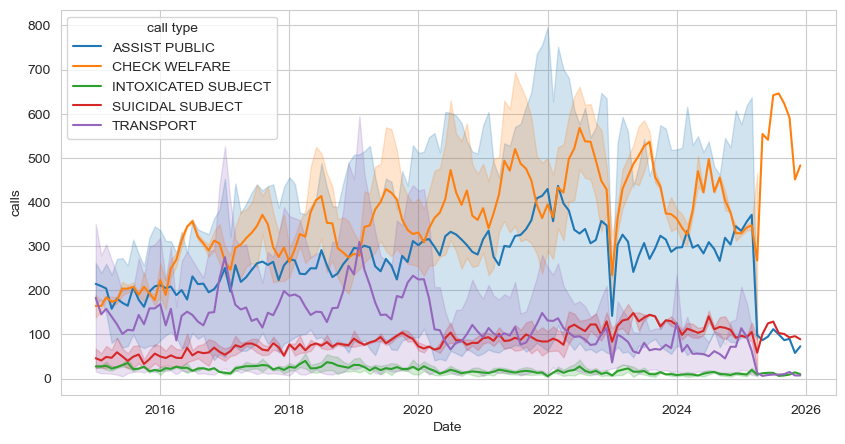

In [1112]:
plt.figure(figsize=(10,5))

sns.lineplot(data = EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

<Axes: xlabel='Date', ylabel='calls'>

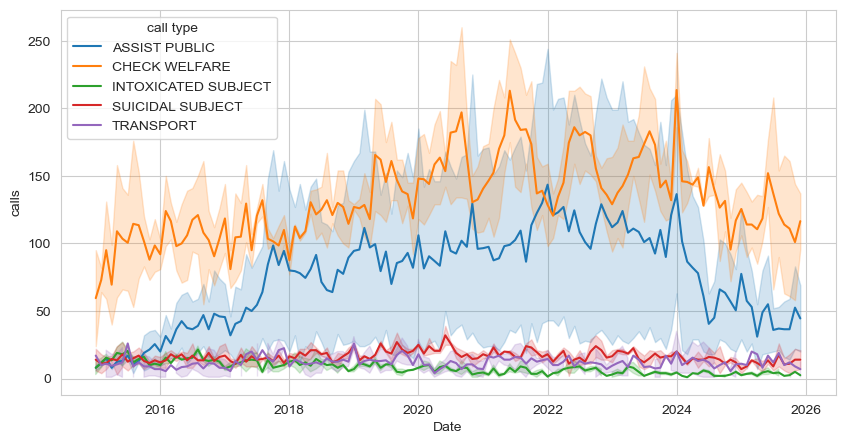

In [1113]:
plt.figure(figsize=(10,5))

sns.lineplot(data = SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

<Axes: xlabel='Date', ylabel='calls'>

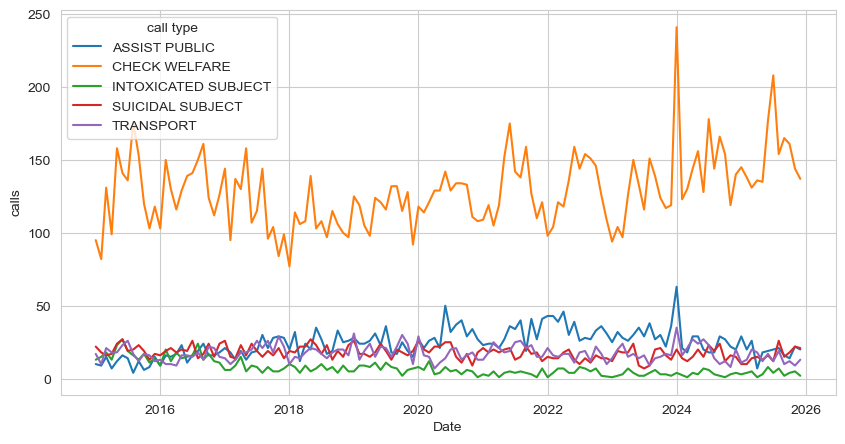

In [1114]:
plt.figure(figsize=(10,5))

sns.lineplot(data = SPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

<Axes: xlabel='Date', ylabel='calls'>

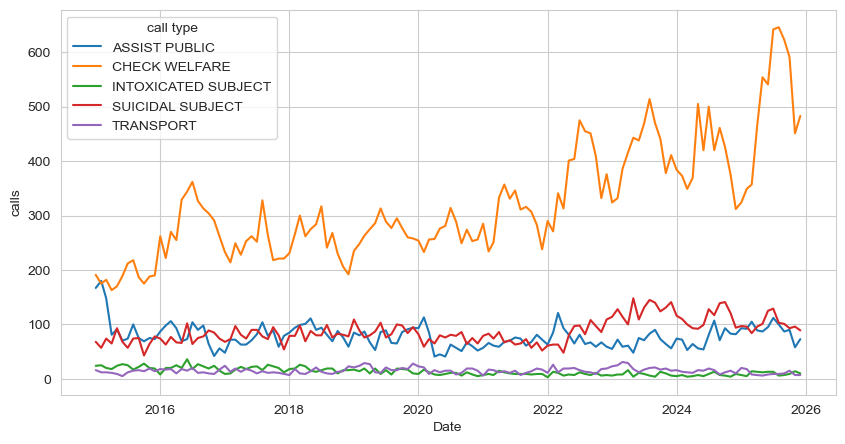

In [1115]:
plt.figure(figsize=(10,5))

sns.lineplot(data = EPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

<Axes: xlabel='Date', ylabel='calls'>

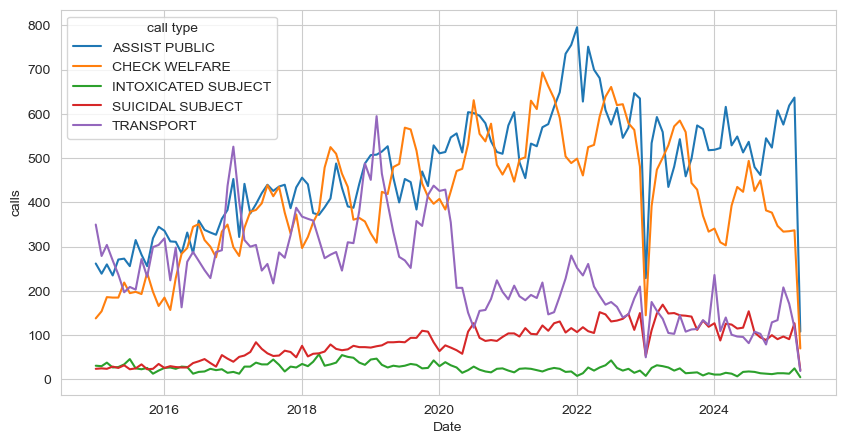

In [1116]:
plt.figure(figsize=(10,5))

sns.lineplot(data = CAHOOTS_EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

In [1117]:
CAHOOTS_EUG_TYPES_VOLUME[CAHOOTS_EUG_TYPES_VOLUME["Date"] == dt.datetime(2025,1,1)]

,Date,call type,agency,calls
1200,2025-01-01,ASSIST PUBLIC,CAHOOTS_EUG,576
1202,2025-01-01,CHECK WELFARE,CAHOOTS_EUG,334
1204,2025-01-01,INTOXICATED SUBJECT,CAHOOTS_EUG,14
1206,2025-01-01,SUICIDAL SUBJECT,CAHOOTS_EUG,97
1208,2025-01-01,TRANSPORT,CAHOOTS_EUG,208


<Axes: xlabel='Date', ylabel='calls'>

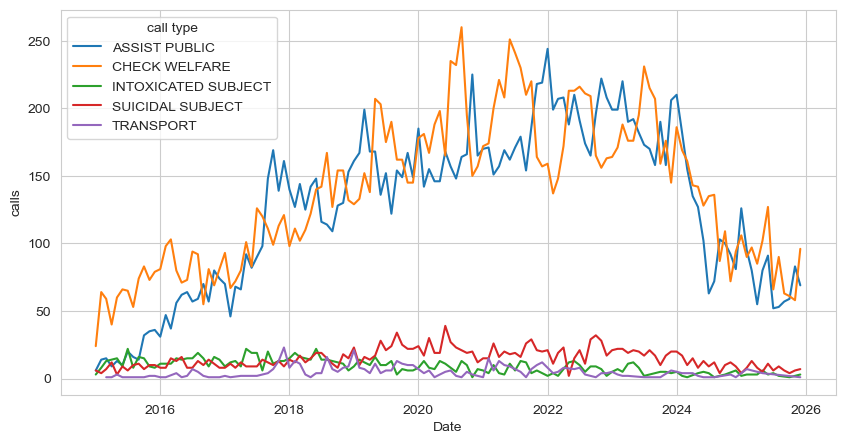

In [1118]:
plt.figure(figsize=(10,5))

sns.lineplot(data = CAHOOTS_SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")

# DiD ANALYSIS

In [1119]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [1120]:
def fit_model(y, x, summary = False):
    y_val = y
    X_val = sm.add_constant(x)

    model = sm.OLS(y_val, X_val).fit()

    if summary == True:
        print(model.summary())
    return model

def fit_DID(df, summary = False):
    model = smf.ols(
        "value ~ treated + post + treated:post",
         data = df
    ).fit()
    if summary == True:
        print(model.summary())
    return model

In [1121]:
#Converting dates to numeric variables

import matplotlib.dates as mdates
TOTAL_EUG_VOLUME["Date_numeric"] = mdates.date2num(TOTAL_EUG_VOLUME["Date"])
TOTAL_SPR_VOLUME["Date_numeric"] = mdates.date2num(TOTAL_SPR_VOLUME["Date"])


In [1122]:
#segmenting data by pre and post CAHOOTS closure
TOTAL_EUG_VOLUME["post"] = (TOTAL_EUG_VOLUME["Date"] > CAHOOTS_closure).astype(int)
TOTAL_EUG_VOLUME["treated"] = 1
TOTAL_SPR_VOLUME["post"] = (TOTAL_SPR_VOLUME["Date"] > CAHOOTS_closure).astype(int)
TOTAL_SPR_VOLUME["treated"] = 0

EUG_VOLUME_PRE = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["post"] == True]
EUG_VOLUME_POST = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["post"] == False]

SPR_VOLUME_PRE = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["post"] == True]
SPR_VOLUME_POST = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["post"] == False]

In [1123]:
TOTAL_EUG_VOLUME_tidy = TOTAL_EUG_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["EPD_CALLS", "MCSLC_EUG_CALLS", "CH_EUG_CALLS"])
TOTAL_SPR_VOLUME_tidy = TOTAL_SPR_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["SPD_CALLS", "MCSLC_SPR_CALLS", "CH_SPR_CALLS"])


TOTAL_EUG_PROP_tidy = TOTAL_EUG_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["PROP_EPD", "PROP_CAHOOTS_EUG", "PROP_MCSLC_EUG"])
TOTAL_SPR_PROP_tidy = TOTAL_SPR_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["PROP_SPD", "PROP_CAHOOTS_SPR", "PROP_MCSLC_SPR"])

In [1124]:
TOTAL_EUG_SPR_PROP = pd.concat([TOTAL_EUG_PROP_tidy, TOTAL_SPR_PROP_tidy])
#TOTAL_EUG_SPR_PROP

In [1125]:
TOTAL_EUG_SPR_VOLUME = pd.concat([TOTAL_EUG_VOLUME_tidy, TOTAL_SPR_VOLUME_tidy])
#TOTAL_EUG_SPR_VOLUME

In [1126]:
EPD_SPD_VOLUME = TOTAL_EUG_SPR_VOLUME[TOTAL_EUG_SPR_VOLUME["variable"].isin(["EPD_CALLS", "SPD_CALLS"])]
EPD_SPD_VOLUME

,Date,Date_numeric,post,treated,variable,value
0,2015-01-01,16436.0,0,1,EPD_CALLS,9223.0
1,2015-02-01,16467.0,0,1,EPD_CALLS,8809.0
2,2015-03-01,16495.0,0,1,EPD_CALLS,9663.0
3,2015-04-01,16526.0,0,1,EPD_CALLS,9395.0
4,2015-05-01,16556.0,0,1,EPD_CALLS,9432.0
...,...,...,...,...,...,...
127,2025-08-01,20301.0,1,0,SPD_CALLS,3523.0
128,2025-09-01,20332.0,1,0,SPD_CALLS,3242.0
129,2025-10-01,20362.0,1,0,SPD_CALLS,3440.0
130,2025-11-01,20393.0,1,0,SPD_CALLS,2996.0


In [1127]:
#pre closure pd regression

EPD_VOLUME_PRE = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 1]
EPD_VOLUME_PRE = EPD_VOLUME_PRE[EPD_VOLUME_PRE["post"] == 0]

EPD_VOLUME_POST = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 1]
EPD_VOLUME_POST = EPD_VOLUME_POST[EPD_VOLUME_POST["post"] == 1]

SPD_VOLUME_PRE = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 0]
SPD_VOL_PRE = SPD_VOLUME_PRE[SPD_VOLUME_PRE["post"] == 0]

SPD_VOLUME_POST = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 0]
SPD_VOLUME_POST = SPD_VOLUME_POST[SPD_VOLUME_POST["post"] == 1]

In [1128]:
#VOLUME REGRESSION MODELS
Model_EPD_PRE = fit_model(EPD_VOLUME_PRE["value"], EPD_VOLUME_PRE["Date_numeric"])
EPD_VOLUME_PRE["prediction"] = Model_EPD_PRE.predict()

Model_EPD_POST = fit_model(EPD_VOLUME_POST["value"], EPD_VOLUME_POST["Date_numeric"])
EPD_VOLUME_POST["prediction"] = Model_EPD_POST.predict()

Model_SPD_PRE = fit_model(SPD_VOLUME_PRE["value"], SPD_VOLUME_PRE["Date_numeric"])
SPD_VOLUME_PRE["prediction"] = Model_SPD_PRE.predict()

Model_SPD_POST = fit_model(SPD_VOLUME_POST["value"], SPD_VOLUME_POST["Date_numeric"])
SPD_VOLUME_POST["prediction"] = Model_SPD_POST.predict()

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_20367/3624998873.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SPD_VOLUME_PRE["prediction"] = Model_SPD_PRE.predict()


In [1129]:
model_pd_vol = fit_DID(EPD_SPD_VOLUME, summary=True)
EPD_SPD_VOLUME["prediction"] = model_pd_vol.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2029.
Date:                Sun, 24 May 2026   Prob (F-statistic):          5.17e-180
Time:                        18:43:48   Log-Likelihood:                -2057.7
No. Observations:                 264   AIC:                             4123.
Df Residuals:                     260   BIC:                             4138.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3999.0000     53.133     75.264   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_20367/4239110583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_VOLUME["prediction"] = model_pd_vol.predict()


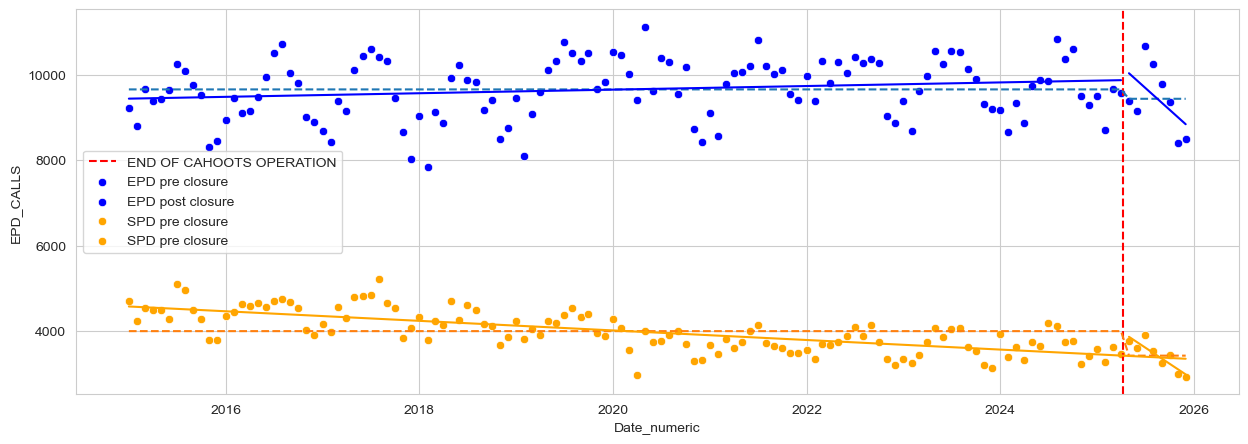

In [1130]:
plt.figure(figsize=(15,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EUG_VOLUME_PRE, x = "Date_numeric", y = "EPD_CALLS", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = EUG_VOLUME_POST, x = "Date_numeric", y = "EPD_CALLS", label = "EPD post closure", color = "blue")

sns.scatterplot(data = SPR_VOLUME_PRE, x = "Date_numeric", y = "SPD_CALLS", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = SPR_VOLUME_POST, x = "Date_numeric", y = "SPD_CALLS", label = "SPD pre closure", color = "orange")


plt.plot(EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "EPD_CALLS"]["Date_numeric"], EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "EPD_CALLS"]["prediction"], linestyle = "--")
plt.plot(EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "SPD_CALLS"]["Date_numeric"], EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "SPD_CALLS"]["prediction"], linestyle = "--")

plt.plot(EPD_VOLUME_PRE["Date_numeric"], EPD_VOLUME_PRE["prediction"], color = "blue")
plt.plot(EPD_VOLUME_POST["Date_numeric"], EPD_VOLUME_POST["prediction"], color = "blue")

plt.plot(SPD_VOLUME_PRE["Date_numeric"], SPD_VOLUME_PRE["prediction"], color = "orange")
plt.plot(SPD_VOLUME_POST["Date_numeric"], SPD_VOLUME_POST["prediction"], color = "orange")

## EPD/SPD CALL PROPORTIONS

In [1131]:
EPD_SPD_PROP = TOTAL_EUG_SPR_PROP[TOTAL_EUG_SPR_PROP["variable"].isin(["PROP_EPD", "PROP_SPD"])]

In [1132]:
#pre closure pd regression

EPD_PROP_PRE = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 1]
EPD_PROP_PRE = EPD_PROP_PRE[EPD_PROP_PRE["post"] == 0]

EPD_PROP_POST = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 1]
EPD_PROP_POST = EPD_PROP_POST[EPD_PROP_POST["post"] == 1]

SPD_PROP_PRE = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 0]
SPD_PROP_PRE = SPD_PROP_PRE[SPD_PROP_PRE["post"] == 0]

SPD_PROP_POST = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 0]
SPD_PROP_POST = SPD_PROP_POST[SPD_PROP_POST["post"] == 1]

In [1133]:
#Proportion OLS Model Fitting

Model_EPD_PRE = fit_model(EPD_PROP_PRE["value"], EPD_PROP_PRE["Date_numeric"])
EPD_PROP_PRE["prediction"] = Model_EPD_PRE.predict()

Model_EPD_POST = fit_model(EPD_PROP_POST["value"], EPD_PROP_POST["Date_numeric"])
EPD_PROP_POST["prediction"] = Model_EPD_POST.predict()

Model_SPD_PRE = fit_model(SPD_PROP_PRE["value"], SPD_PROP_PRE["Date_numeric"])
SPD_PROP_PRE["prediction"] = Model_SPD_PRE.predict()

Model_SPD_POST = fit_model(SPD_PROP_POST["value"], SPD_PROP_POST["Date_numeric"])
SPD_PROP_POST["prediction"] = Model_SPD_POST.predict()

In [1134]:
#EPD/SPD DID

model_pd_prop = fit_DID(EPD_SPD_PROP, summary=True)
EPD_SPD_PROP["prediction"] = model_pd_prop.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     84.20
Date:                Sun, 24 May 2026   Prob (F-statistic):           4.32e-38
Time:                        18:43:48   Log-Likelihood:                 586.54
No. Observations:                 264   AIC:                            -1165.
Df Residuals:                     260   BIC:                            -1151.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9188      0.002    387.021   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_20367/3684267554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_PROP["prediction"] = model_pd_prop.predict()


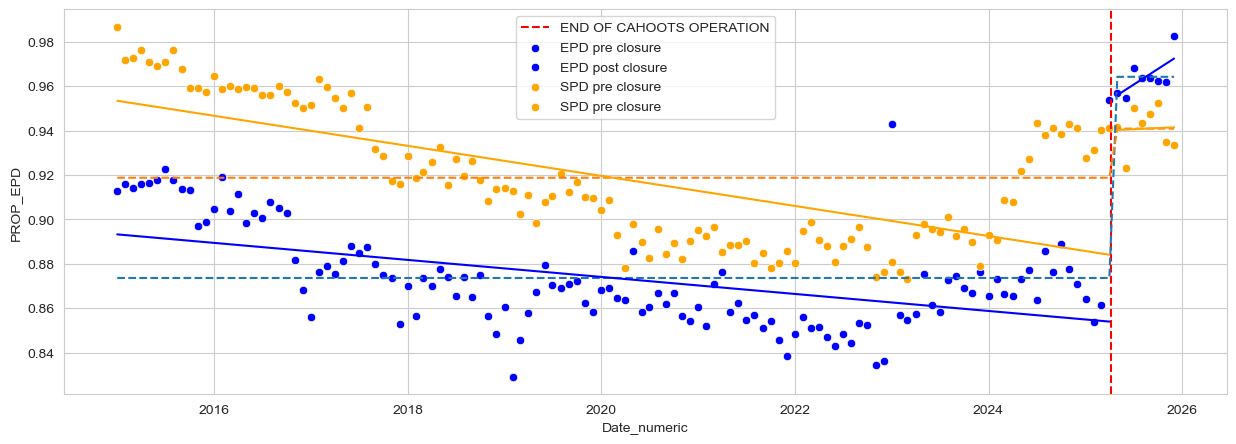

In [1135]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EUG_VOLUME_PRE, x = "Date_numeric", y = "PROP_EPD", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = EUG_VOLUME_POST, x = "Date_numeric", y = "PROP_EPD", label = "EPD post closure", color = "blue")

sns.scatterplot(data = SPR_VOLUME_PRE, x = "Date_numeric", y = "PROP_SPD", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = SPR_VOLUME_POST, x = "Date_numeric", y = "PROP_SPD", label = "SPD pre closure", color = "orange")


#plt.plot(EPD_SPD_PROP["Date_numeric"], y_pred, label="Regression Line")
plt.plot(EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_EPD"]["Date_numeric"], EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_EPD"]["prediction"], linestyle = "--")
plt.plot(EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_SPD"]["Date_numeric"], EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_SPD"]["prediction"], linestyle = "--")

plt.plot(EPD_PROP_PRE["Date_numeric"], EPD_PROP_PRE["prediction"], color = "blue")
plt.plot(EPD_PROP_POST["Date_numeric"], EPD_PROP_POST["prediction"], color = "blue")

plt.plot(SPD_PROP_PRE["Date_numeric"], SPD_PROP_PRE["prediction"], color = "orange")
plt.plot(SPD_PROP_POST["Date_numeric"], SPD_PROP_POST["prediction"], color = "orange")

In [1136]:
EPD_SPD_PROP_RESULTS = EPD_SPD_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_PROP_RESULTS

,treated,post,variable,prediction
0,0,0,PROP_SPD,0.918770
1,0,1,PROP_SPD,0.940907
2,1,0,PROP_EPD,0.873597
3,1,1,PROP_EPD,0.964266


## MCSLC VOLUME DID

In [1137]:
MCSLC_TOTAL_VOLUME = TOTAL_EUG_SPR_VOLUME[TOTAL_EUG_SPR_VOLUME["variable"].isin(["MCSLC_EUG_CALLS", "MCSLC_SPR_CALLS"])]
MCSLC_TOTAL_VOLUME = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["value"] > 0]
MCSLC_TOTAL_VOLUME = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["Date"] != dt.datetime(2025, 12, 1)]

In [1138]:
#pre closure MCSLC regression

MCSLC_EUG_VOLUME_PRE = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 1]
MCSLC_EUG_VOLUME_PRE = MCSLC_EUG_VOLUME_PRE[MCSLC_EUG_VOLUME_PRE["post"] == 0]

MCSLC_EUG_VOLUME_POST = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 1]
MCSLC_EUG_VOLUME_POST = MCSLC_EUG_VOLUME_POST[MCSLC_EUG_VOLUME_POST["post"] == 1]

MCSLC_SPR_VOLUME_PRE = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 0]
MCSLC_SPR_VOLUME_PRE = MCSLC_SPR_VOLUME_PRE[MCSLC_SPR_VOLUME_PRE["post"] == 0]

MCSLC_SPR_VOLUME_POST = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 0]
MCSLC_SPR_VOLUME_POST = MCSLC_SPR_VOLUME_POST[MCSLC_SPR_VOLUME_POST["post"] == 1]


In [1139]:
#OLS models

Model_MCSLC_EUG_PRE = fit_model(MCSLC_EUG_VOLUME_PRE["value"], MCSLC_EUG_VOLUME_PRE["Date_numeric"])
MCSLC_EUG_VOLUME_PRE["prediction"] = Model_MCSLC_EUG_PRE.predict()

Model_MCSLC_EUG_POST = fit_model(MCSLC_EUG_VOLUME_POST["value"], MCSLC_EUG_VOLUME_POST["Date_numeric"])
MCSLC_EUG_VOLUME_POST["prediction"] = Model_MCSLC_EUG_POST.predict()

Model_MCLSC_SPR_PRE = fit_model(MCSLC_SPR_VOLUME_PRE["value"], MCSLC_SPR_VOLUME_PRE["Date_numeric"])
MCSLC_SPR_VOLUME_PRE["prediction"] = Model_MCLSC_SPR_PRE.predict()

Model_MCSLC_SPR_POST = fit_model(MCSLC_SPR_VOLUME_POST["value"], MCSLC_SPR_VOLUME_POST["Date_numeric"])
MCSLC_SPR_VOLUME_POST["prediction"] = Model_MCSLC_SPR_POST.predict()

In [1140]:
#MCSLC DID model

Model_MCSLC_vol = fit_DID(MCSLC_TOTAL_VOLUME, summary=True)
MCSLC_TOTAL_VOLUME["prediction"] = Model_MCSLC_vol.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     134.8
Date:                Sun, 24 May 2026   Prob (F-statistic):           3.76e-15
Time:                        18:43:49   Log-Likelihood:                -139.73
No. Observations:                  28   AIC:                             287.5
Df Residuals:                      24   BIC:                             292.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.5714     14.522      0.935   

In [1141]:
MCSLC_TOTAL_VOLUME.head()

,Date,Date_numeric,post,treated,variable,value,prediction
247,2024-08-01,19936.0,0,1,MCSLC_EUG_CALLS,56.0,109.142857
248,2024-09-01,19967.0,0,1,MCSLC_EUG_CALLS,120.0,109.142857
249,2024-10-01,19997.0,0,1,MCSLC_EUG_CALLS,15.0,109.142857
252,2025-01-01,20089.0,0,1,MCSLC_EUG_CALLS,92.0,109.142857
253,2025-02-01,20120.0,0,1,MCSLC_EUG_CALLS,116.0,109.142857


In [1142]:
MCSLC_EUG_VOLUME_PRE

,Date,Date_numeric,post,treated,variable,value,prediction
247,2024-08-01,19936.0,0,1,MCSLC_EUG_CALLS,56.0,44.267460
248,2024-09-01,19967.0,0,1,MCSLC_EUG_CALLS,120.0,60.192756
249,2024-10-01,19997.0,0,1,MCSLC_EUG_CALLS,15.0,75.604332
252,2025-01-01,20089.0,0,1,MCSLC_EUG_CALLS,92.0,122.866499
253,2025-02-01,20120.0,0,1,MCSLC_EUG_CALLS,116.0,138.791794
254,2025-03-01,20148.0,0,1,MCSLC_EUG_CALLS,141.0,153.175932
255,2025-04-01,20179.0,0,1,MCSLC_EUG_CALLS,224.0,169.101227


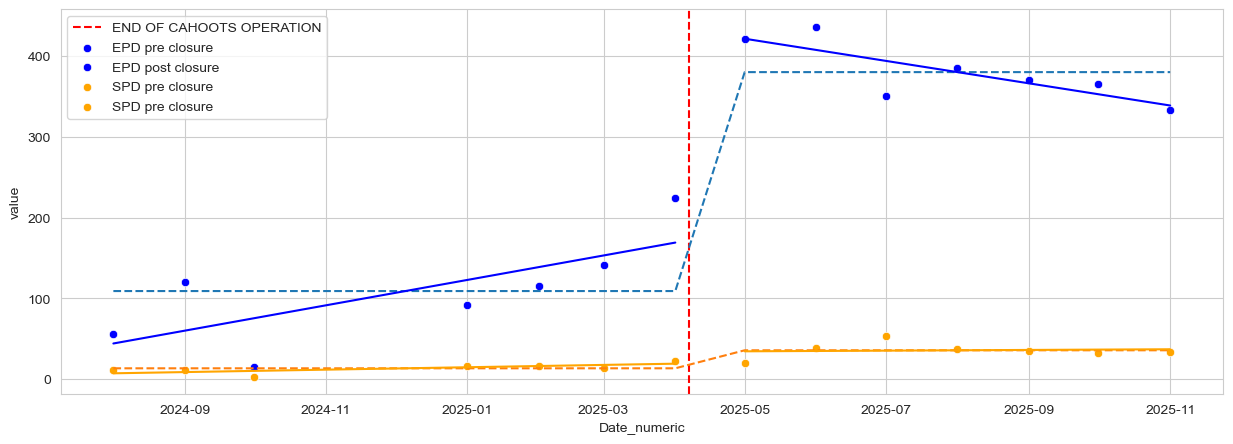

In [1143]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = MCSLC_EUG_VOLUME_PRE, x = "Date_numeric", y = "value", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = MCSLC_EUG_VOLUME_POST, x = "Date_numeric", y = "value", label = "EPD post closure", color = "blue")

sns.scatterplot(data = MCSLC_SPR_VOLUME_PRE, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = MCSLC_SPR_VOLUME_POST, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")


#plt.plot(MCSLC_TOTAL_VOLUME["Date_numeric"], y_pred, label="Regression Line")
plt.plot(MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_EUG_CALLS"]["Date_numeric"], MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_EUG_CALLS"]["prediction"], linestyle = "--")
plt.plot(MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_SPR_CALLS"]["Date_numeric"], MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_SPR_CALLS"]["prediction"], linestyle = "--")

plt.plot(MCSLC_EUG_VOLUME_PRE["Date_numeric"], MCSLC_EUG_VOLUME_PRE["prediction"], color = "blue")
plt.plot(MCSLC_SPR_VOLUME_POST["Date_numeric"], MCSLC_EUG_VOLUME_POST["prediction"], color = "blue")

plt.plot(MCSLC_SPR_VOLUME_PRE["Date_numeric"], MCSLC_SPR_VOLUME_PRE["prediction"], color = "orange")
plt.plot(MCSLC_SPR_VOLUME_POST["Date_numeric"], MCSLC_SPR_VOLUME_POST["prediction"], color = "orange")

In [1144]:
MCSLC_VOLUME_RESULTS = MCSLC_TOTAL_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
MCSLC_VOLUME_RESULTS

,treated,post,variable,prediction
0,0,0,MCSLC_SPR_CALLS,13.571429
1,0,1,MCSLC_SPR_CALLS,35.857143
2,1,0,MCSLC_EUG_CALLS,109.142857
3,1,1,MCSLC_EUG_CALLS,380.000000


## MCSLC PROPORTION DID

In [1145]:
MCSLC_TOTAL_PROP = TOTAL_EUG_SPR_PROP[TOTAL_EUG_SPR_PROP["variable"].isin(["PROP_MCSLC_EUG", "PROP_MCSLC_SPR"])]
MCSLC_TOTAL_PROP = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["value"] > 0]
MCSLC_TOTAL_PROP = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["Date"] != dt.datetime(2025, 12, 1)]

In [1146]:
#pre closure MCSLC regression

MCSLC_EUG_PROP_PRE = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 1]
MCSLC_EUG_PROP_PRE = MCSLC_EUG_PROP_PRE[MCSLC_EUG_PROP_PRE["post"] == 0]

MCSLC_EUG_PROP_POST = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 1]
MCSLC_EUG_PROP_POST = MCSLC_EUG_PROP_POST[MCSLC_EUG_PROP_POST["post"] == 1]

MCSLC_SPR_PROP_PRE = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 0]
MCSLC_SPR_PROP_PRE = MCSLC_SPR_PROP_PRE[MCSLC_SPR_PROP_PRE["post"] == 0]

MCSLC_SPR_PROP_POST = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 0]
MCSLC_SPR_PROP_POST = MCSLC_SPR_PROP_POST[MCSLC_SPR_PROP_POST["post"] == 1]


In [1147]:
#OLS models

Model_MCSLC_EUG_PRE = fit_model(MCSLC_EUG_PROP_PRE["value"], MCSLC_EUG_PROP_PRE["Date_numeric"])
MCSLC_EUG_PROP_PRE["prediction"] = Model_MCSLC_EUG_PRE.predict()

Model_MCSLC_EUG_POST = fit_model(MCSLC_EUG_PROP_POST["value"], MCSLC_EUG_PROP_POST["Date_numeric"])
MCSLC_EUG_PROP_POST["prediction"] = Model_MCSLC_EUG_POST.predict()

Model_MCLSC_SPR_PRE = fit_model(MCSLC_SPR_PROP_PRE["value"], MCSLC_SPR_PROP_PRE["Date_numeric"])
MCSLC_SPR_PROP_PRE["prediction"] = Model_MCLSC_SPR_PRE.predict()

Model_MCSLC_SPR_POST = fit_model(MCSLC_SPR_PROP_POST["value"], MCSLC_SPR_PROP_POST["Date_numeric"])
MCSLC_SPR_PROP_POST["prediction"] = Model_MCSLC_SPR_POST.predict()

In [1148]:
#MCSLC DID model

Model_MCSLC_prop = fit_DID(MCSLC_TOTAL_PROP, summary=True)
MCSLC_TOTAL_PROP["prediction"] = Model_MCSLC_prop.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     91.32
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.89e-13
Time:                        18:43:49   Log-Likelihood:                 114.91
No. Observations:                  28   AIC:                            -221.8
Df Residuals:                      24   BIC:                            -216.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0035      0.002      2.177   

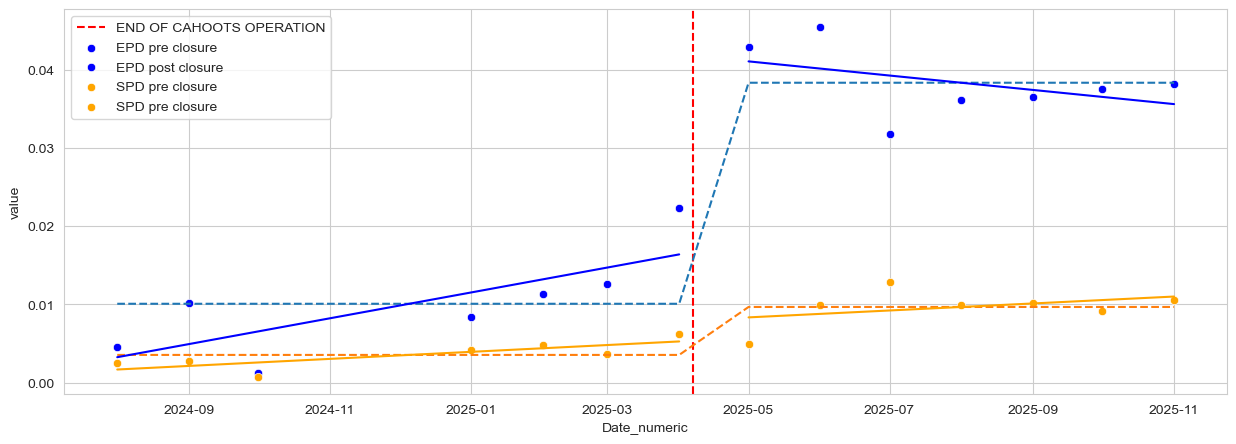

In [1149]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = MCSLC_EUG_PROP_PRE, x = "Date_numeric", y = "value", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = MCSLC_EUG_PROP_POST, x = "Date_numeric", y = "value", label = "EPD post closure", color = "blue")

sns.scatterplot(data = MCSLC_SPR_PROP_PRE, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = MCSLC_SPR_PROP_POST, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")


#plt.plot(MCSLC_TOTAL_PROP["Date_numeric"], y_pred, label="Regression Line")
plt.plot(MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_EUG"]["Date_numeric"], MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_EUG"]["prediction"], linestyle = "--")
plt.plot(MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_SPR"]["Date_numeric"], MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_SPR"]["prediction"], linestyle = "--")

plt.plot(MCSLC_EUG_PROP_PRE["Date_numeric"], MCSLC_EUG_PROP_PRE["prediction"], color = "blue")
plt.plot(MCSLC_SPR_PROP_POST["Date_numeric"], MCSLC_EUG_PROP_POST["prediction"], color = "blue")

plt.plot(MCSLC_SPR_PROP_PRE["Date_numeric"], MCSLC_SPR_PROP_PRE["prediction"], color = "orange")
plt.plot(MCSLC_SPR_PROP_POST["Date_numeric"], MCSLC_SPR_PROP_POST["prediction"], color = "orange")

In [1150]:
MCSLC_PROP_RESULTS = MCSLC_TOTAL_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
MCSLC_PROP_RESULTS

,treated,post,variable,prediction
0,0,0,PROP_MCSLC_SPR,0.003550
1,0,1,PROP_MCSLC_SPR,0.009684
2,1,0,PROP_MCSLC_EUG,0.010092
3,1,1,PROP_MCSLC_EUG,0.038363
